# Analysis Visualizations
Covers:
- **A.** Affine R² layer-pair heatmaps + diagonal comparison across models
- **E.** Controls (shuffle baseline, layer-0 baseline, permutation null distributions)
- **G.** SVD (spectrum across layers, trajectory metrics by category, pairwise cosine gap, joint A-B cosine)

In [1]:
import json, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

REPO = "/juice6/u/jshe/nlp/LM_neural_synchrony"
AFFINE_BASE = os.path.join(REPO, "affine_transformation")
SAVE_DIR = os.path.join(REPO, "playground", "viz_outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_DISPLAY = {
    "Misv0.3Misv0.3": "Mis-v0.3 × Mis-v0.3",
    "Misv0.3Misv0.2": "Mis-v0.3 × Mis-v0.2",
    "Misv0.2Misv0.3": "Mis-v0.2 × Mis-v0.3",
    "Misv0.2Misv0.2": "Mis-v0.2 × Mis-v0.2",
}

N_LAYERS = 32


def subplots_2col(n_panels, row_h=5.0, col_w=7.0, **kwargs):
    """Two columns; hide unused axes. Returns fig, first n_panels axes, nrows, ncols."""
    ncols = 2
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(col_w * ncols, row_h * nrows),
        squeeze=False,
        **kwargs,
    )
    axes_flat = np.array(axes).reshape(-1)
    for j in range(n_panels, len(axes_flat)):
        axes_flat[j].set_visible(False)
    return fig, axes_flat[:n_panels].tolist(), nrows, ncols


def set_xlabel_bottom_row(axes_list, nrows, ncols, xlabel):
    """Set x-axis label on axes in the bottom row of a row-major 2-column grid."""
    if not axes_list:
        return
    n = len(axes_list)
    first_bottom = (nrows - 1) * ncols
    for i in range(n):
        if i >= first_bottom:
            axes_list[i].set_xlabel(xlabel)

---
## A. Affine R² — Layer-Pair Heatmaps

In [2]:
def load_affine_heatmap(model_tag, setting="A_forward", data_mode="combined_metrics"):
    """Load 32x32 R² matrix from per-layer JSON files."""
    r2 = np.full((N_LAYERS, N_LAYERS), np.nan)
    base = os.path.join(AFFINE_BASE, setting)
    for la in range(N_LAYERS):
        data_dir = os.path.join(base, f"layerA{la}", "data")
        if not os.path.isdir(data_dir):
            continue
        for lb in range(N_LAYERS):
            fn = os.path.join(
                data_dir,
                f"{data_mode}_{model_tag}[0, 1, 2, 3, 4]_layerA{la}_layerB{lb}_allreps.json"
            )
            if not os.path.exists(fn):
                continue
            with open(fn) as f:
                d = json.load(f)
            if model_tag in d:
                vals = d[model_tag]["r2_mean"]
                r2[la, lb] = vals[0] if isinstance(vals, list) else vals
    return r2

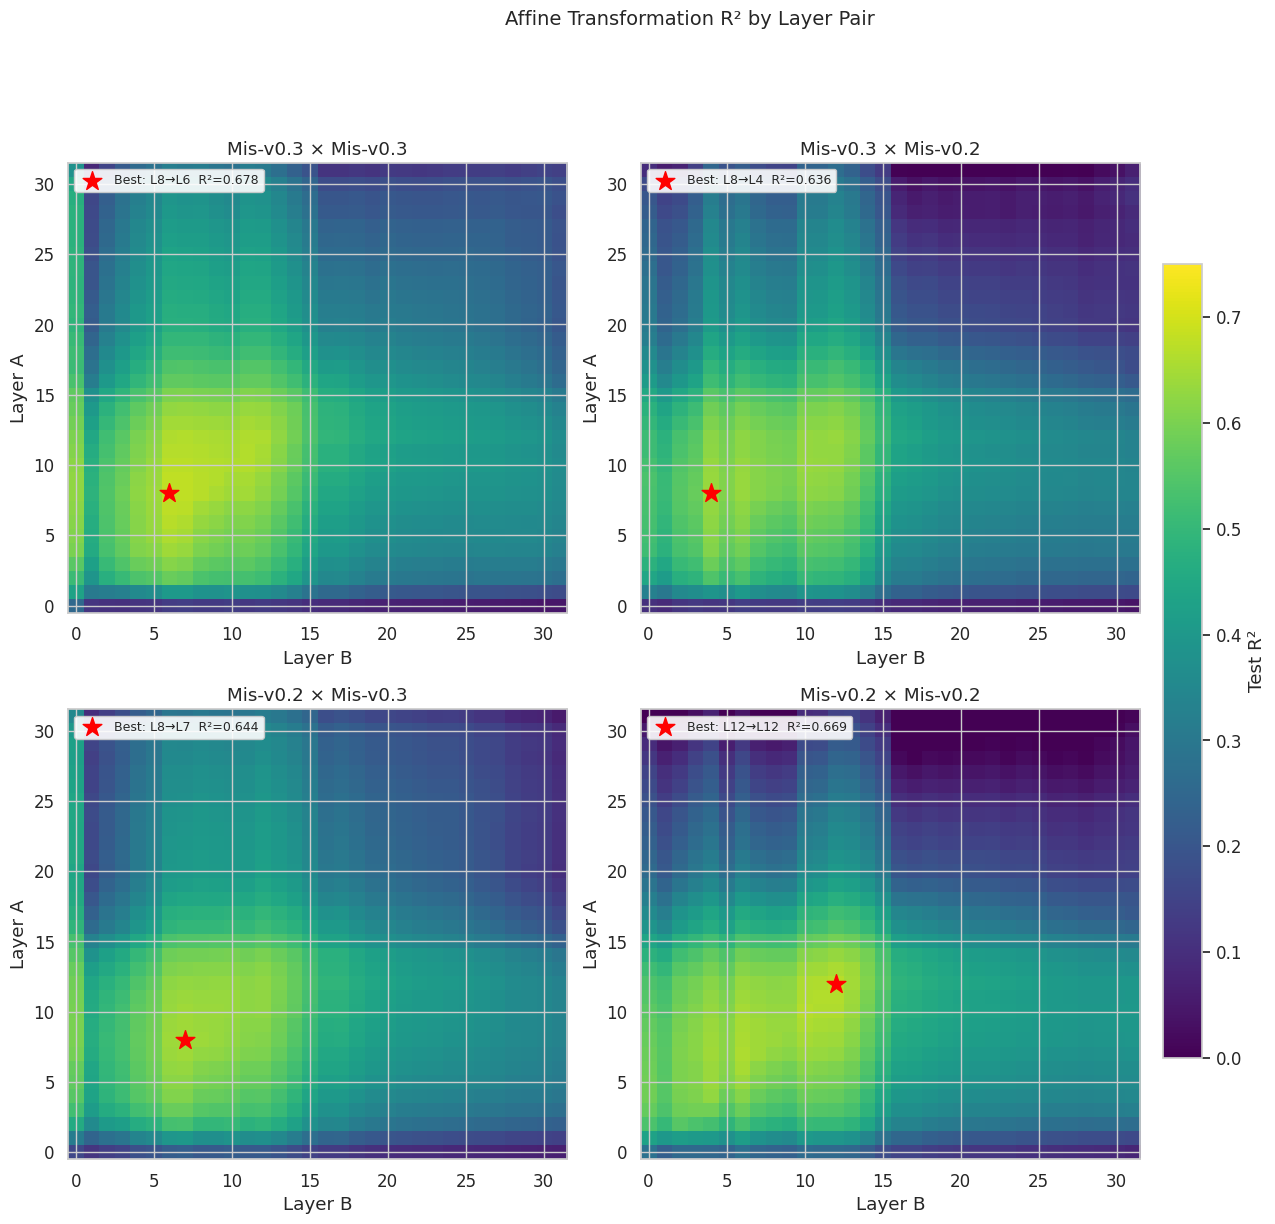

In [3]:
affine_models = ["Misv0.3Misv0.3", "Misv0.3Misv0.2", "Misv0.2Misv0.3", "Misv0.2Misv0.2"]

n = len(affine_models)
fig, axes, _, _ = subplots_2col(n, row_h=6.0, col_w=7.0)

vmin, vmax = 0, 0.75
im = None
for ax, tag in zip(axes, affine_models):
    r2 = load_affine_heatmap(tag)
    im = ax.imshow(r2, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax,
                   aspect="auto", interpolation="nearest")
    if np.any(np.isfinite(r2)):
        best_idx = np.unravel_index(np.nanargmax(r2), r2.shape)
        ax.scatter(
            best_idx[1], best_idx[0], marker="*", s=200, c="red", zorder=5,
            label=f"Best: L{best_idx[0]}→L{best_idx[1]}  R²={r2[best_idx]:.3f}",
        )
        ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
    else:
        ax.text(
            0.5, 0.5,
            "No R² data for this pair\n(no matching JSON under affine_transformation/)",
            ha="center", va="center", transform=ax.transAxes, fontsize=10,
        )
    ax.set_xlabel("Layer B")
    ax.set_ylabel("Layer A")
    ax.set_title(MODEL_DISPLAY.get(tag, tag))

fig.suptitle("Affine Transformation R² by Layer Pair", fontsize=14, y=1.02)
# Reserve right margin so the colorbar sits outside the heatmap axes (not on top of them)
fig.tight_layout(rect=[0.0, 0.0, 0.88, 0.96])
fig.colorbar(
    im,
    ax=axes,
    shrink=0.82,
    label="Test R²",
    location="right",
    pad=0.02,
    fraction=0.035,
)
fig.savefig(os.path.join(SAVE_DIR, "A1_layer_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

### A2. SBERT controls — grouped bars per model pair

For each pair: **best hidden-layer R²** (max over the affine heatmap, same as A1), **SBERT** aligned turn pairing, **episode-shuffled** B prompts, and **cross-turn** B offsets \(t\), \(t+1\), \(t+5\).

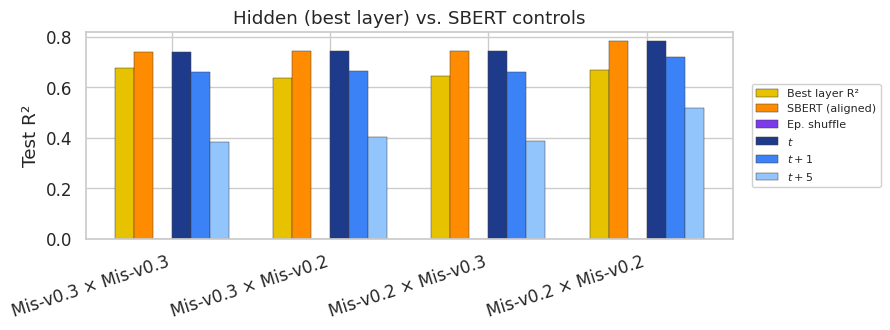

In [17]:
with open(os.path.join(REPO, "control_analysis_sbert_summary.json")) as f:
    sbert_by_model = {e["model"]: e for e in json.load(f)}

affine_models = ["Misv0.3Misv0.3", "Misv0.3Misv0.2", "Misv0.2Misv0.3", "Misv0.2Misv0.2"]
bar_labels = ["Best layer R²", "SBERT (aligned)", "Ep. shuffle", r"$t$", r"$t+1$", r"$t+5$"]
bar_colors = ["#E6C200", "#FF8C00", "#7C3AED", "#1E3A8A", "#3B82F6", "#93C5FD"]

best_hidden, sbert_align, shuf_r2 = [], [], []
ct0, ct1, ct5 = [], [], []
for tag in affine_models:
    r2 = load_affine_heatmap(tag)
    if np.any(np.isfinite(r2)):
        best_hidden.append(float(np.nanmax(r2)))
    else:
        best_hidden.append(float("nan"))
    e = sbert_by_model.get(tag)
    sbert_align.append(e["sbert"]["real_r2_mean"])
    shuf_r2.append(e["shuffle_episode_text"]["shuffled_r2_mean"])
    ct = e["cross_turn"]
    ct0.append(ct["offset_0"]["real_r2_mean"])
    ct1.append(ct["offset_1"]["real_r2_mean"])
    ct5.append(ct["offset_5"]["real_r2_mean"])

series = [best_hidden, sbert_align, shuf_r2, ct0, ct1, ct5]
n_models = len(affine_models)
n_bars = len(series)
x = np.arange(n_models, dtype=float)
width = 0.12
group_span = width * n_bars
offsets = x[:, None] + (np.arange(n_bars) - (n_bars - 1) / 2) * width

fig, ax = plt.subplots(figsize=(11, 3.5))
for j in range(n_bars):
    ax.bar(
        offsets[:, j],
        [series[j][i] for i in range(n_models)],
        width,
        label=bar_labels[j],
        color=bar_colors[j],
        edgecolor="0.25",
        linewidth=0.35,
    )
ax.set_xticks(x)
ax.set_xticklabels([MODEL_DISPLAY.get(t, t) for t in affine_models], rotation=18, ha="right")
ax.set_ylabel("Test R²")
ax.set_ylim(0, 0.82)
ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.18), framealpha=0.92)
ax.set_title("Hidden (best layer) vs. SBERT controls")
ax.legend(
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # move outside right
    framealpha=0.92
)

fig.tight_layout(rect=[0, 0, 0.82, 1])  # leave space on right

fig.savefig(os.path.join(SAVE_DIR, "A2_sbert_controls_grouped.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## E. Controls

In [5]:
with open(os.path.join(REPO, "control_analysis_summary.json")) as f:
    controls_data = json.load(f)

print(f"Loaded controls for {len(controls_data)} model pairs")
for entry in controls_data:
    print(f"  {entry['model']}  L{entry['layer_A']}→L{entry['layer_B']}")

Loaded controls for 4 model pairs
  Misv0.3Misv0.3  L26→L26
  Misv0.3Misv0.2  L26→L26
  Misv0.2Misv0.3  L26→L26
  Misv0.2Misv0.2  L26→L26


---
## G. SVD Analysis (v2 + k-fold CV)

In [7]:
with open(os.path.join(REPO, "svd_v2_cv_summary.json")) as f:
    svd_data = json.load(f)

svd_models = [e["model"] for e in svd_data]
print(f"Loaded SVD v2 CV results for: {svd_models}")

Loaded SVD v2 CV results for: ['Misv0.3Misv0.3', 'Misv0.3Misv0.2', 'Misv0.2Misv0.3', 'Misv0.2Misv0.2']


### G1. Singular Value Spectrum (top-k explained variance) Across Layers

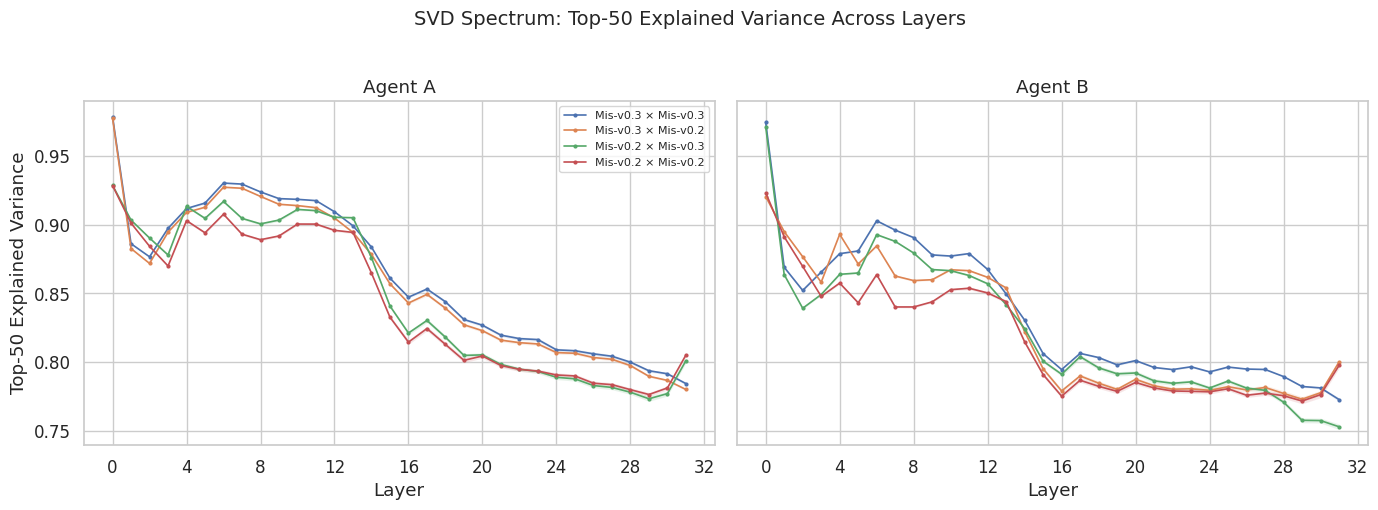

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, agent_key, agent_label in zip(axes, ["agent_A", "agent_B"], ["Agent A", "Agent B"]):
    for entry in svd_data:
        model = entry["model"]
        agent = entry[agent_key]
        layers_sorted = sorted(agent.keys(), key=lambda k: int(k[1:]))
        layer_nums = [int(k[1:]) for k in layers_sorted]
        explained = [agent[k]["spectrum"]["top_k_explained"] for k in layers_sorted]
        explained_std = [agent[k]["spectrum"]["top_k_explained_std"] for k in layers_sorted]
        ax.plot(layer_nums, explained, marker=".", markersize=4, linewidth=1.2,
                label=MODEL_DISPLAY.get(model, model))
        ax.fill_between(layer_nums,
                        np.array(explained) - np.array(explained_std),
                        np.array(explained) + np.array(explained_std),
                        alpha=0.15)
    ax.set_xlabel("Layer")
    ax.set_title(agent_label)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(4))

axes[0].set_ylabel("Top-50 Explained Variance")
axes[0].legend(fontsize=8)
fig.suptitle("SVD Spectrum: Top-50 Explained Variance Across Layers", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "G1_svd_spectrum.png"), dpi=150, bbox_inches="tight")
plt.show()

### G2. Mean step cosine

1. **vs layer:** mean $\cos(\mathbf{z}_t, \mathbf{z}_{t+1})$ in CV SVD space, averaged over all turns in each test episode, then by category — **every model pair**, Agent A, for `task_structure` and `outcome_correspondence`.

2. **vs turn:** at each step $t$, mean step cosine within each category (test episodes only), **one subplot row per layer** in `TURN_CURVE_LAYERS`. Requires `per_turn_step_cosine` in the SVD JSON; re-run `analyze_svd.py` after updating the analysis script if this key is missing.


In [18]:
def extract_trajectory_metric_by_layer(entry, agent_key, dimension, metric):
    """Extract one trajectory metric (e.g. mean_step_cosine) per category across layers."""
    agent = entry[agent_key]
    layers_sorted = sorted(agent.keys(), key=lambda k: int(k[1:]))
    layer_nums = [int(k[1:]) for k in layers_sorted]

    all_cats = set()
    for lk in layers_sorted:
        traj = agent[lk].get("trajectory_metrics", {})
        dim_data = traj.get(dimension, {})
        metric_data = dim_data.get(metric, {})
        all_cats.update(metric_data.keys())

    result = {}
    for cat in sorted(all_cats):
        means, stds = [], []
        for lk in layers_sorted:
            traj = agent[lk].get("trajectory_metrics", {})
            dim_data = traj.get(dimension, {})
            metric_data = dim_data.get(metric, {})
            if cat in metric_data:
                means.append(metric_data[cat]["mean"])
                stds.append(metric_data[cat].get("std_across_folds", 0))
            else:
                means.append(np.nan)
                stds.append(0)
        result[cat] = {"means": means, "stds": stds}
    return layer_nums, result

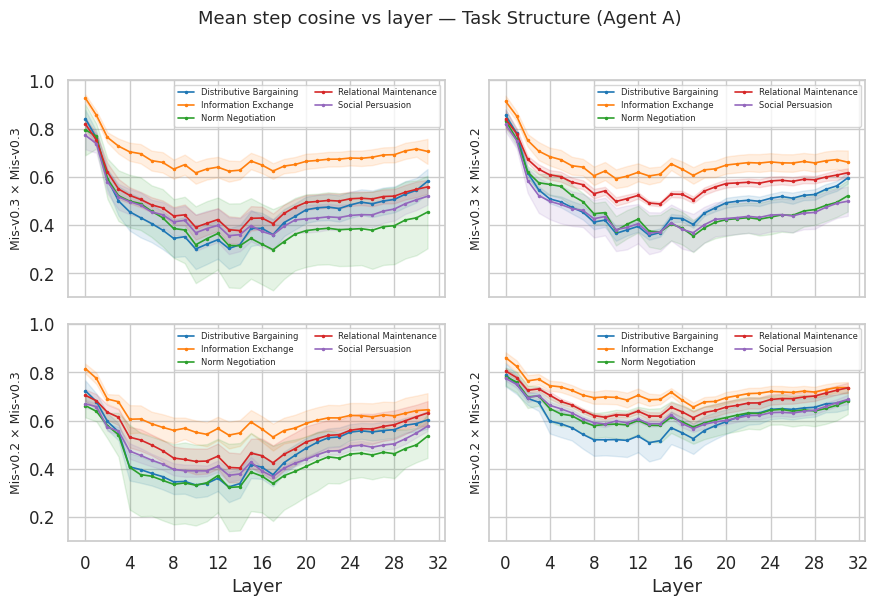

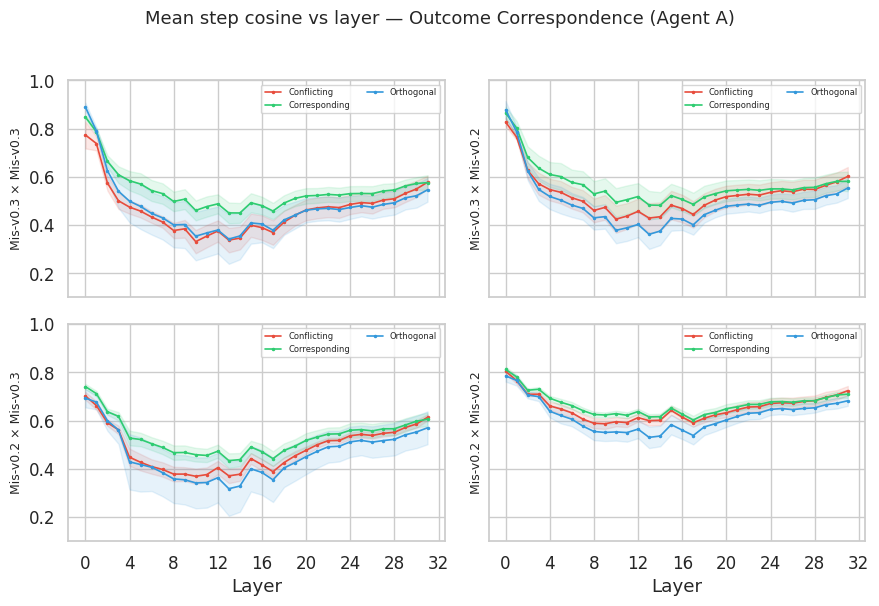

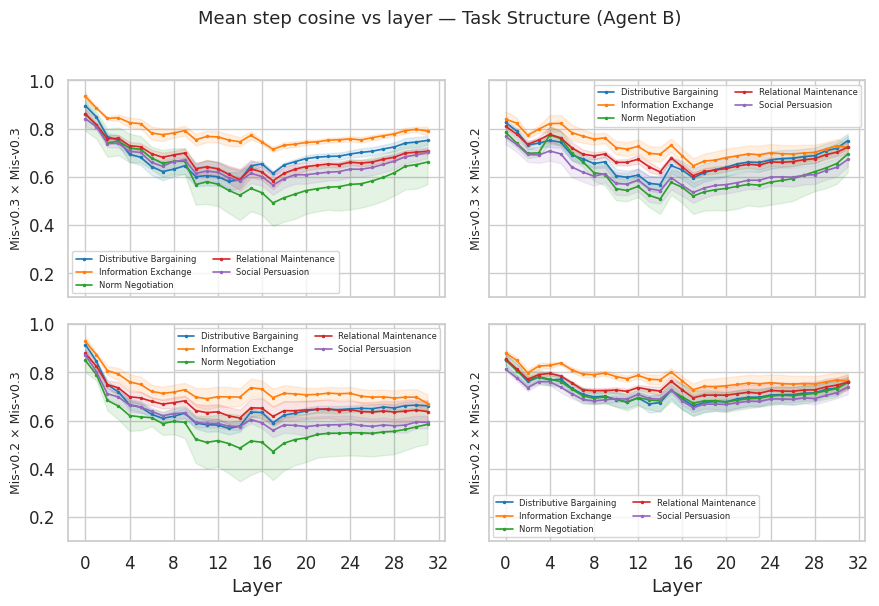

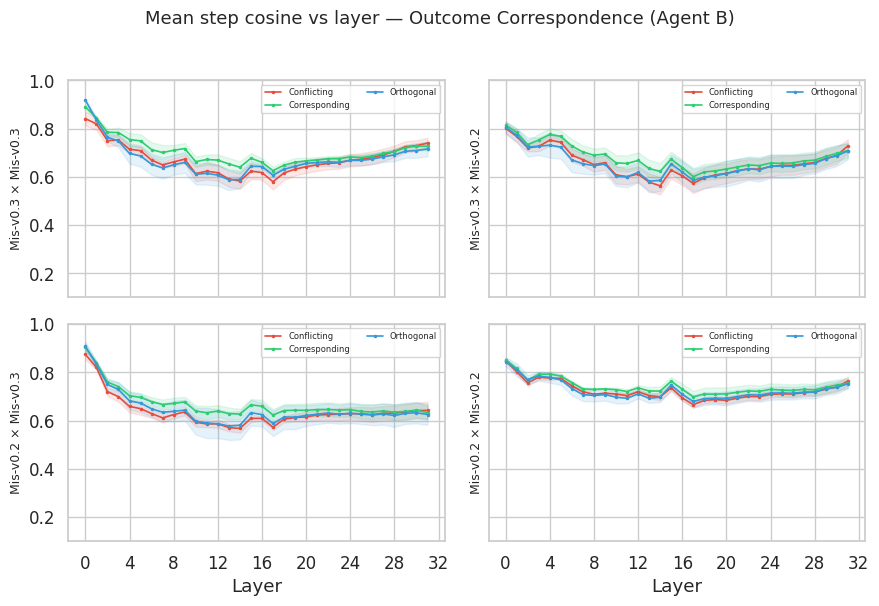

In [ ]:
CAT_COLORS = {
    "distributive_bargaining": "#1f77b4",
    "information_exchange": "#ff7f0e",
    "norm_negotiation": "#2ca02c",
    "relational_maintenance": "#d62728",
    "social_persuasion": "#9467bd",
    "conflicting": "#e74c3c",
    "corresponding": "#2ecc71",
    "orthogonal": "#3498db",
}

# Layers for per-turn trajectory panels (one matplotlib axes row each)
TURN_CURVE_LAYERS = [8, 16, 31]

METRIC = "mean_step_cosine"

# --- G2a: mean step cosine vs layer, all model pairs ---
for agent_key, agent_label in [("agent_A", "Agent A"), ("agent_B", "Agent B")]:
    for dimension in ["task_structure", "outcome_correspondence"]:
        n = len(svd_data)
        fig, axes, nrows, ncols = subplots_2col(n, row_h=3.0, col_w=4.5, sharex=True, sharey=True)
        fig.suptitle(
            f"Mean step cosine vs layer — {dimension.replace('_', ' ').title()} ({agent_label})",
            fontsize=13, y=1.01,
        )
        for ax, entry in zip(axes, svd_data):
            layer_nums, cat_data = extract_trajectory_metric_by_layer(
                entry, agent_key, dimension, METRIC)
            for cat, vals in cat_data.items():
                color = CAT_COLORS.get(cat, None)
                ax.plot(
                    layer_nums, vals["means"], marker=".", markersize=3, linewidth=1.2,
                    label=str(cat).replace("_", " ").title(), color=color,
                )
                ax.fill_between(
                    layer_nums,
                    np.array(vals["means"]) - np.array(vals["stds"]),
                    np.array(vals["means"]) + np.array(vals["stds"]),
                    alpha=0.12, color=color,
                )
            ax.set_ylabel(MODEL_DISPLAY.get(entry["model"], entry["model"]), fontsize=9)
            ax.xaxis.set_major_locator(mticker.MultipleLocator(4))
            # Cosine is in [-1, 1]; keep full range so lines are never clipped off-screen
            ax.set_ylim(0.1,1)
            ax.legend(fontsize=6, loc="best", ncol=2)
        set_xlabel_bottom_row(axes, nrows, ncols, "Layer")
        fig.tight_layout()
        fig.savefig(
            os.path.join(SAVE_DIR, f"G2a_mean_step_cosine_layers_{agent_key}_{dimension}.png"),
            dpi=150, bbox_inches="tight",
        )
        plt.show()


def plot_per_turn_panels(entry, agent_key, layers, dimension, cat_colors, title_prefix):
    """One panel per layer (2 columns): mean cos(z_t, z_{t+1}) vs turn index t by category."""
    agent = entry[agent_key]
    n_layers = len(layers)
    fig, axes, nrows, ncols = subplots_2col(n_layers, row_h=2.8, col_w=7.0, sharex=True)
    for ax, layer in zip(axes, layers):
        lk = f"L{layer}"
        if lk not in agent:
            ax.text(0.5, 0.5, f"Missing {lk}", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"Layer {layer}")
            continue
        block = agent[lk].get("per_turn_step_cosine")
        if not block or dimension not in block:
            ax.text(
                0.5, 0.5,
                f"No per_turn_step_cosine for {lk}\n(JSON missing this field — regenerate SVD summary)",
                ha="center", va="center", transform=ax.transAxes, fontsize=10,
                color="#b22222", fontweight="semibold", wrap=True,
            )
            ax.set_title(f"Layer {layer}")
            continue
        dim_data = block[dimension]
        for cat in sorted(dim_data.keys()):
            series = dim_data[cat]
            y = series["turn_means"]
            ystd = series.get("turn_means_std_across_folds")
            x = np.arange(len(y))
            color = cat_colors.get(cat, None)
            lab = str(cat).replace("_", " ").title()
            ax.plot(x, y, marker=".", markersize=3, linewidth=1.2, label=lab, color=color)
            if ystd is not None and len(ystd) == len(y):
                y_arr = np.array(y, dtype=float)
                ys = np.array(ystd, dtype=float)
                ax.fill_between(x, y_arr - ys, y_arr + ys, alpha=0.12, color=color)
        ax.set_ylabel(f"L{layer}", fontsize=9)
        ax.set_ylim(0.1, 1)
        ax.legend(fontsize=6, loc="best", ncol=2)
        ax.axhline(0, color="gray", linewidth=0.4, linestyle=":")
    set_xlabel_bottom_row(axes, nrows, ncols, "Turn step t (edge t → t+1 in dialogue)")
    fig.suptitle(title_prefix, fontsize=12, y=1.01)
    fig.tight_layout()
    return fig

### G3. Pairwise Cosine Similarity Gap Across Layers

In [11]:
def extract_cosine_gap_by_layer(entry, agent_key, dimension):
    """Extract same-cat, cross-cat, and gap cosine across layers."""
    agent = entry[agent_key]
    layers_sorted = sorted(agent.keys(), key=lambda k: int(k[1:]))
    layer_nums = [int(k[1:]) for k in layers_sorted]

    same, cross, gap, gap_std = [], [], [], []
    for lk in layers_sorted:
        ps = agent[lk].get("pairwise_similarity", {}).get(dimension, {})
        same.append(ps.get("same_cat_mean", np.nan))
        cross.append(ps.get("cross_cat_mean", np.nan))
        gap.append(ps.get("gap_mean", np.nan))
        gap_std.append(ps.get("gap_std", 0))

    return layer_nums, np.array(same), np.array(cross), np.array(gap), np.array(gap_std)

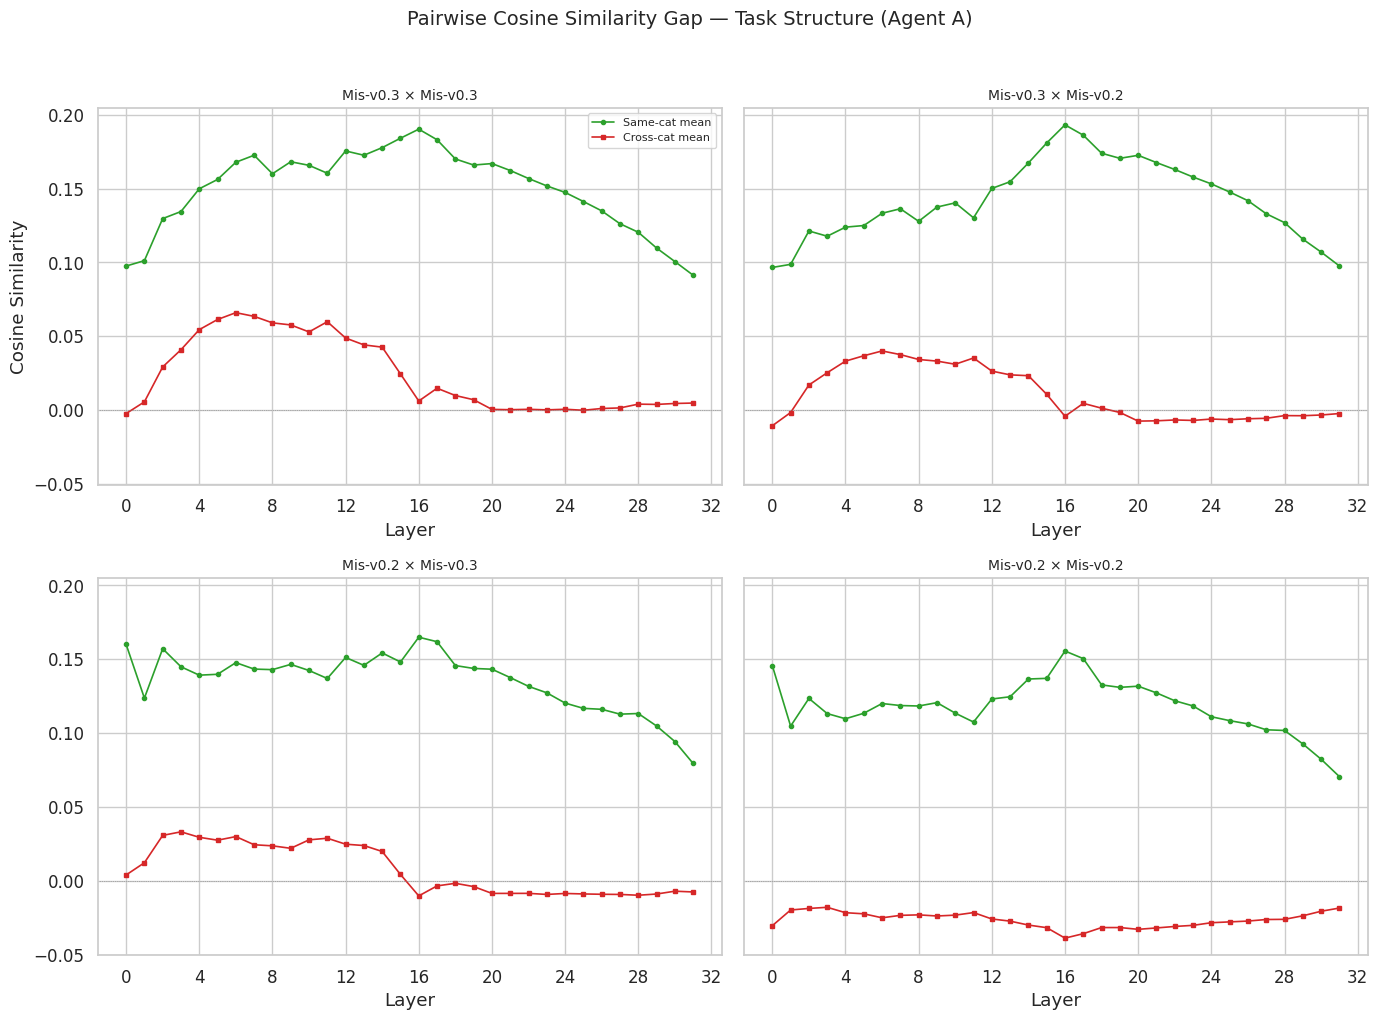

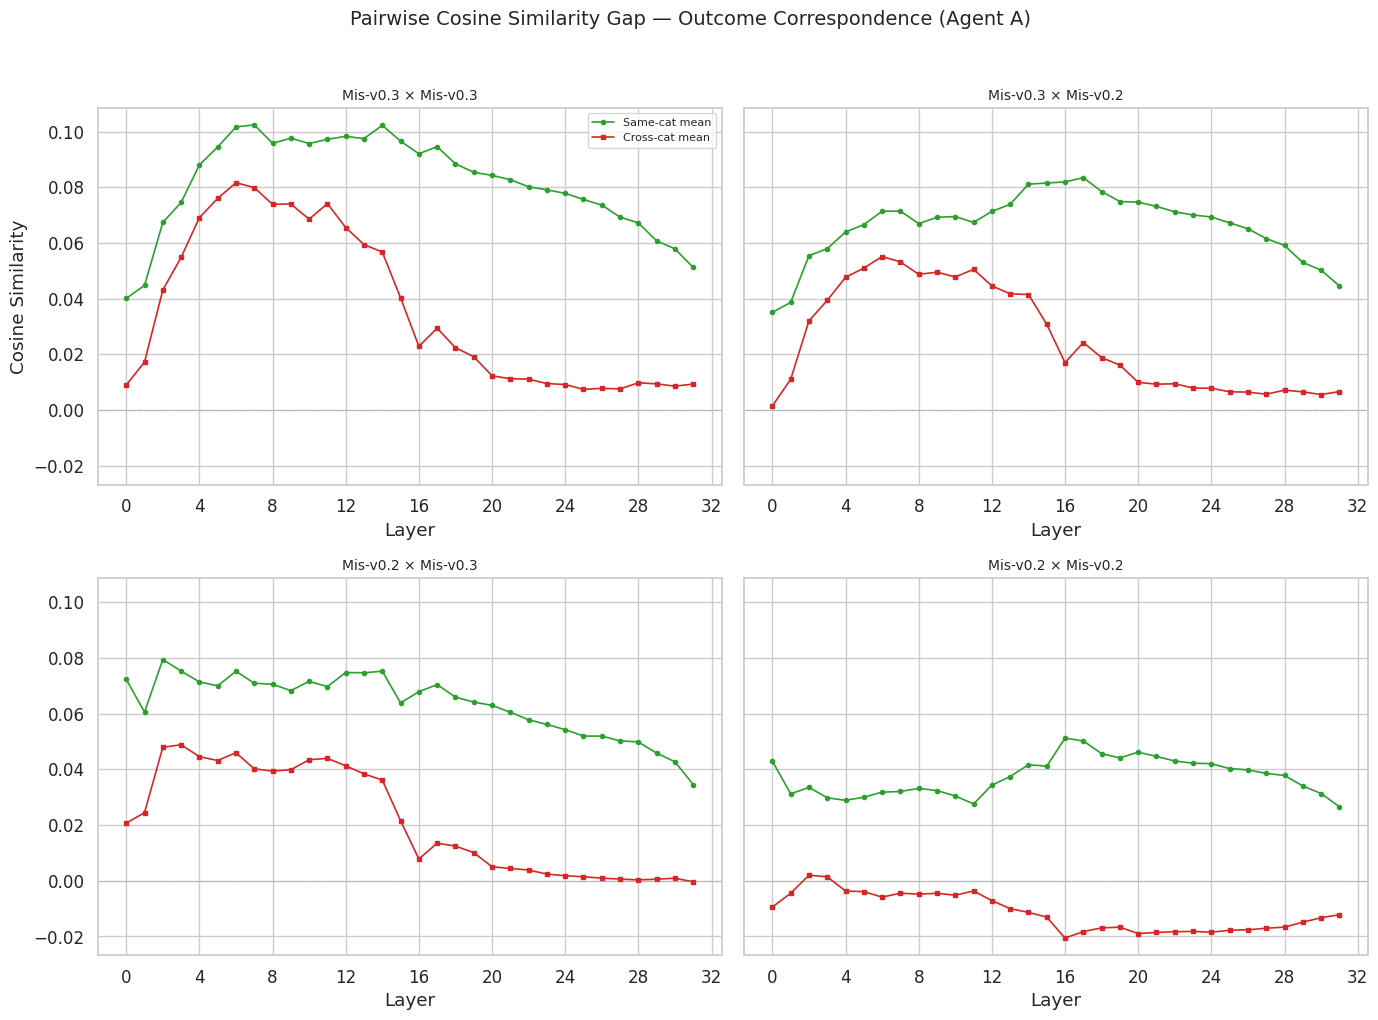

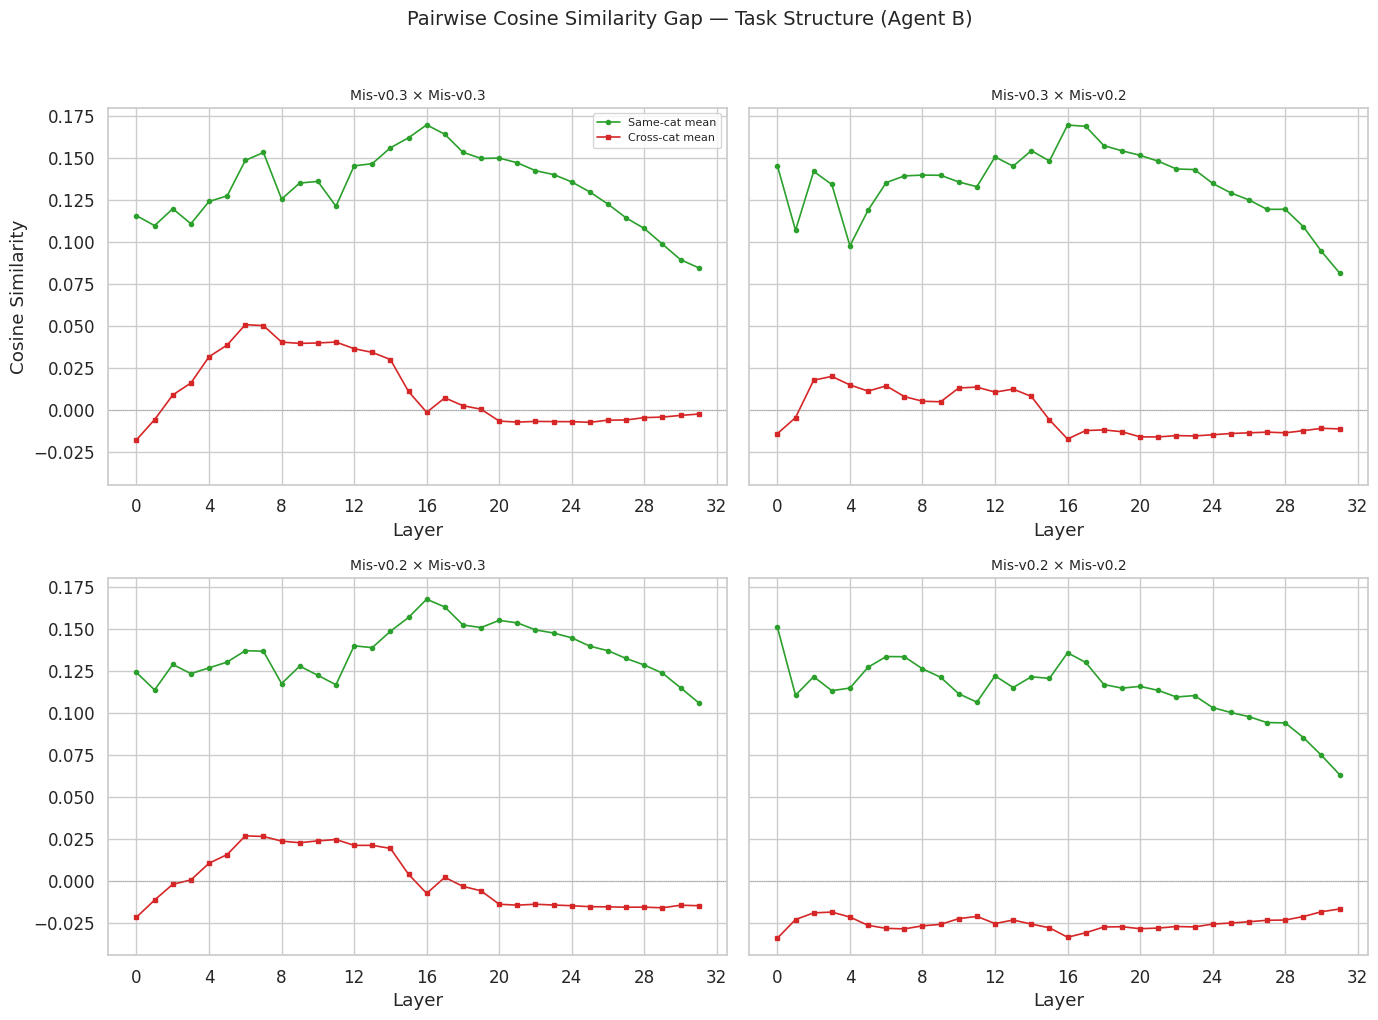

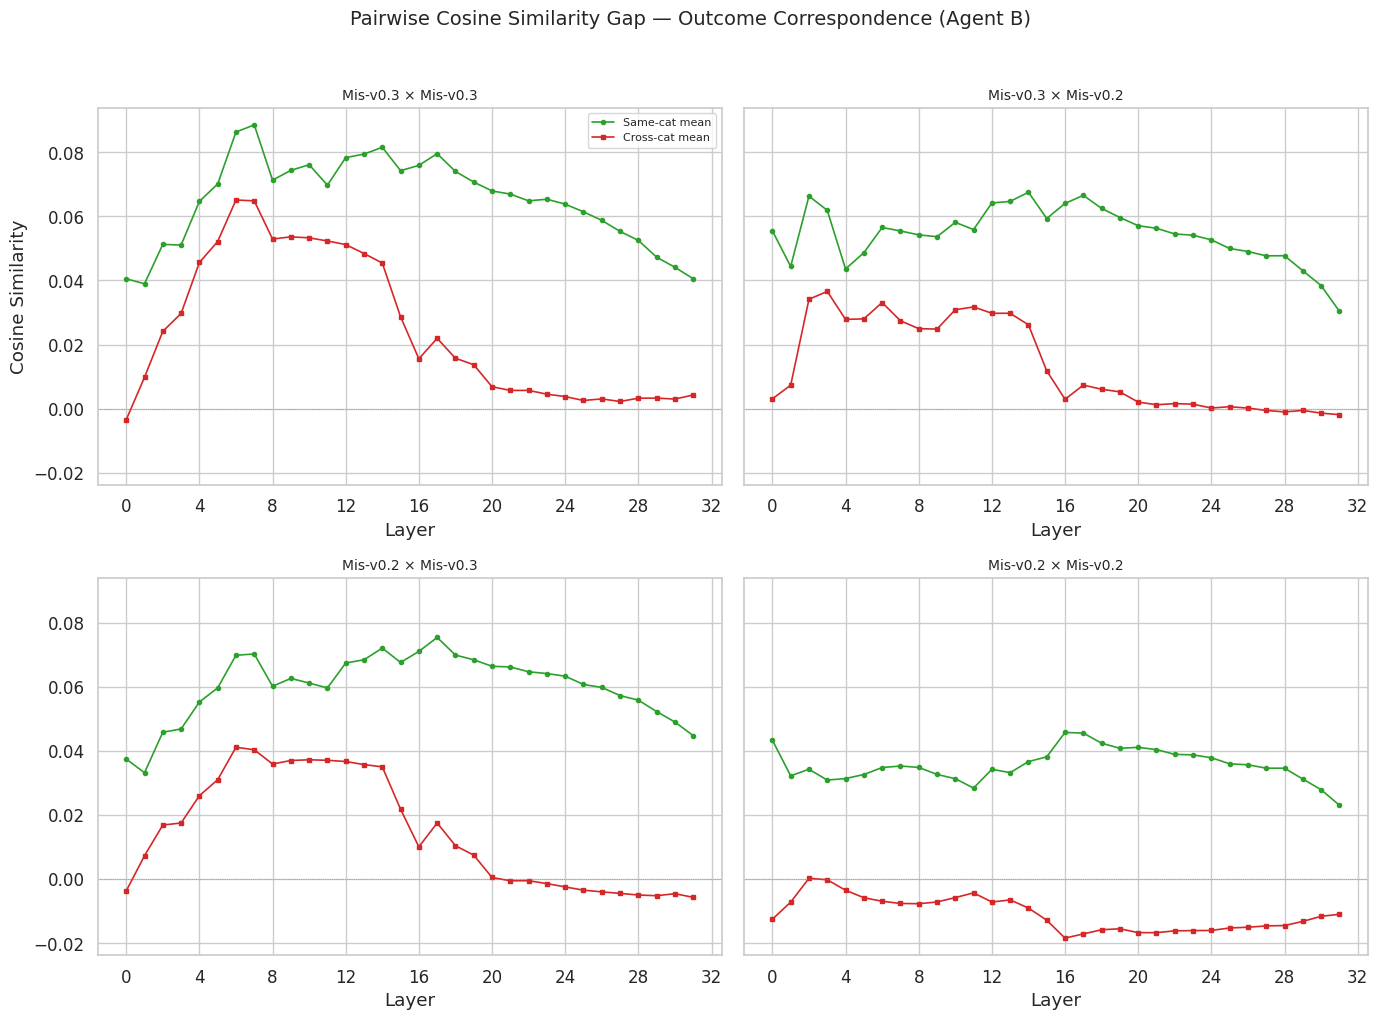

In [26]:
for agent_key, agent_label in [("agent_A", "Agent A"), ("agent_B", "Agent B")]:
    for dimension in ["task_structure", "outcome_correspondence"]:
        n = len(svd_data)
        fig, axes, nrows, ncols = subplots_2col(n, row_h=5.0, col_w=7.0, sharey=True)

        for ax, entry in zip(axes, svd_data):
            model = entry["model"]
            layer_nums, same, cross, gap, gap_std = extract_cosine_gap_by_layer(
                entry, agent_key, dimension)

            if np.all(np.isnan(gap)):
                ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                        ha="center", va="center")
            else:
                ax.plot(layer_nums, same, "o-", markersize=3, linewidth=1.2,
                        color="#2ca02c", label="Same-cat mean")
                ax.plot(layer_nums, cross, "s-", markersize=3, linewidth=1.2,
                        color="#d62728", label="Cross-cat mean")

            ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
            ax.set_xlabel("Layer")
            ax.set_title(MODEL_DISPLAY.get(model, model), fontsize=10)
            ax.xaxis.set_major_locator(mticker.MultipleLocator(4))
            if ax is axes[0]:
                ax.set_ylabel("Cosine Similarity")
                ax.legend(fontsize=8)

        set_xlabel_bottom_row(axes, nrows, ncols, "Layer")

        dim_title = dimension.replace("_", " ").title()
        fig.suptitle(
            f"Pairwise Cosine Similarity Gap — {dim_title} ({agent_label})",
            fontsize=14, y=1.02,
        )
        fig.tight_layout()
        fig.savefig(
            os.path.join(SAVE_DIR, f"G3_cosine_gap_{agent_key}_{dimension}.png"),
            dpi=150, bbox_inches="tight",
        )
        plt.show()

### G4. Joint SVD — Agent A vs. B Cosine Across Layers

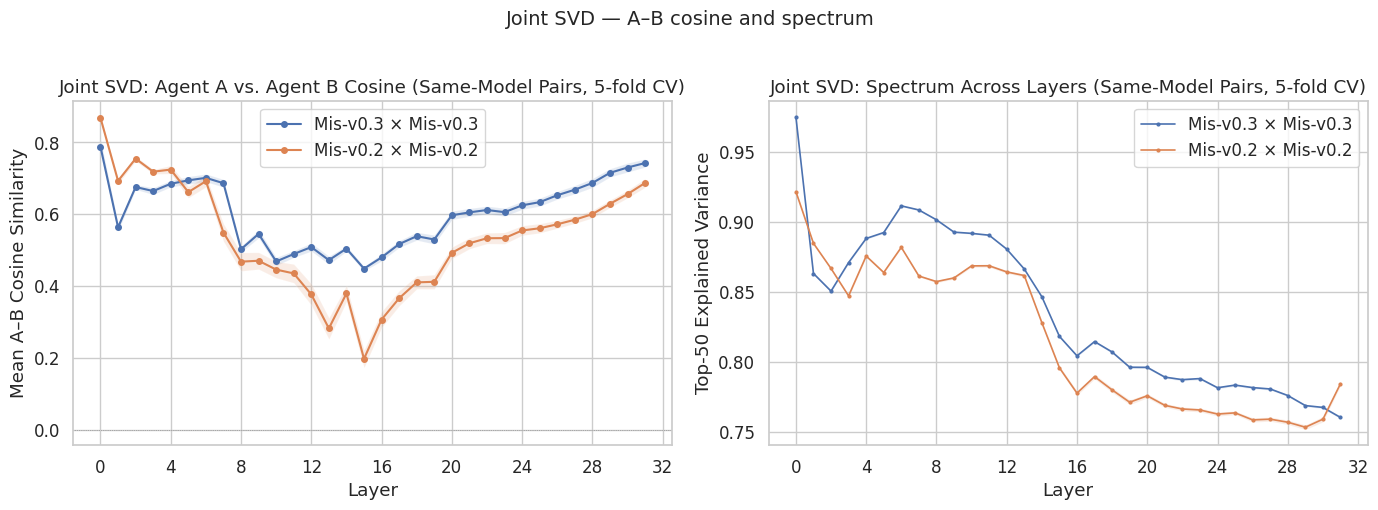

In [21]:
joint_entries = [e for e in svd_data if "joint" in e]

fig, (ax4, ax5) = plt.subplots(1, 2, figsize=(14, 5))

for entry in joint_entries:
    model = entry["model"]
    joint = entry["joint"]
    layers_sorted = sorted(joint.keys(), key=lambda k: int(k[1:]))
    layer_nums = [int(k[1:]) for k in layers_sorted]
    ab_cos = [joint[k]["agent_ab_cosine_mean"] for k in layers_sorted]
    ab_std = [joint[k].get("agent_ab_cosine_std_across_folds", 0) for k in layers_sorted]

    ax4.plot(layer_nums, ab_cos, marker="o", markersize=4, linewidth=1.5,
             label=MODEL_DISPLAY.get(model, model))
    ax4.fill_between(layer_nums,
                     np.array(ab_cos) - np.array(ab_std),
                     np.array(ab_cos) + np.array(ab_std),
                     alpha=0.15)

ax4.set_xlabel("Layer")
ax4.set_ylabel("Mean A–B Cosine Similarity")
ax4.set_title("Joint SVD: Agent A vs. Agent B Cosine (Same-Model Pairs, 5-fold CV)")
ax4.legend()
ax4.xaxis.set_major_locator(mticker.MultipleLocator(4))
ax4.axhline(0, color="gray", linewidth=0.5, linestyle=":")

for entry in joint_entries:
    model = entry["model"]
    joint = entry["joint"]
    layers_sorted = sorted(joint.keys(), key=lambda k: int(k[1:]))
    layer_nums = [int(k[1:]) for k in layers_sorted]
    explained = [joint[k]["spectrum"]["top_k_explained"] for k in layers_sorted]
    explained_std = [joint[k]["spectrum"]["top_k_explained_std"] for k in layers_sorted]

    ax5.plot(layer_nums, explained, marker=".", markersize=4, linewidth=1.2,
             label=MODEL_DISPLAY.get(model, model))
    ax5.fill_between(layer_nums,
                     np.array(explained) - np.array(explained_std),
                     np.array(explained) + np.array(explained_std),
                     alpha=0.15)

ax5.set_xlabel("Layer")
ax5.set_ylabel("Top-50 Explained Variance")
ax5.set_title("Joint SVD: Spectrum Across Layers (Same-Model Pairs, 5-fold CV)")
ax5.legend()
ax5.xaxis.set_major_locator(mticker.MultipleLocator(4))

fig.suptitle("Joint SVD — A–B cosine and spectrum", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "G4_G5_joint_row.png"), dpi=150, bbox_inches="tight")
plt.show()